In [1]:
import pandas as pd 
import kagglehub
import glob
import os
import torch
import torch.nn as nn
import zarr
from geff import read
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:

path = "/kaggle/input/competitions/biohub-cell-tracking-during-development/train"

def download_Data(path, train=True):
    files = glob.glob(os.path.join(path, "*.zarr"))
    files.sort()
    print(f"path: {path}")
    zarrDict = {}
    names = []
    
    if (train == True):
        annotations = glob.glob(os.path.join(path, "*.geff"))
        annotations.sort()
        geffDict ={}
        
        for i in range(len(files)):
            name = os.path.basename(files[i]).replace('.zarr', "")
            names.append(name)
            zarrDict[f"{name}Zarr"] = zarr.open(f"{files[i]}/0")
            geffDict[f"{name}Geff"] =  read(annotations[i])
        return zarrDict, geffDict, names
    else:
         for i in range(len(files)):
            name = os.path.basename(files[i]).replace('.zarr', "")
            names.append(name)
            zarrDict[f"{name}Zarr"] = zarr.open(f"{files[i]}/0")
    return zarrDict, names

    
    
   

zarrDict, geffDict, names = download_Data(path)


path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train


In [3]:

def geff_to_parquet(geffDict):
    node_rows = []
    edge_rows = []
    
    for name, (graph, metadata) in geffDict.items():
        n_row  = metadata.extra.get("estimated_number_of_nodes")
        for node_id, attrs in graph.nodes(data=True):
            
            node_rows.append({
                "file_id": name,
                "id": node_id,
                "t": attrs.get("t"),
                "x": attrs.get("x"),
                "y": attrs.get("y"),
                "z": attrs.get("z"),
                "num": n_row
            })
        for src, tgt, attrs in graph.edges(data=True):
            edge_rows.append({
                "file_id": name,
                "source": src,
                "target": tgt,
                
            })
    
    nodes_df = pd.DataFrame(node_rows)
    edges_df = pd.DataFrame(edge_rows)
    
    nodes_df.to_parquet(f"all_nodes.parquet", index=False)
    edges_df.to_parquet(f"all_edges.parquet", index=False)

geff_to_parquet(geffDict)

In [4]:

class LightweightUNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=16):
        super(LightweightUNet3D, self).__init__()
        
        # Encoder Steps
        self.enc1 = self._conv_block(in_channels, base_filters)
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)
        
        self.enc2 = self._conv_block(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)
        
        # Bottleneck Layer
        self.bottleneck = self._conv_block(base_filters * 2, base_filters * 4)
        
        # Decoder Steps
        self.up2 = nn.ConvTranspose3d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(base_filters * 4, base_filters * 2) 
        
        self.up1 = nn.ConvTranspose3d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(base_filters * 2, base_filters) 
        
        # Final Pointwise Heatmap Projection
        self.final_conv = nn.Conv3d(base_filters, out_channels, kernel_size=1)


        #second output
        self.up2b = nn.ConvTranspose3d(base_filters*4, base_filters *2, kernel_size=2, stride=2)
        self.dec2b = self._conv_block(base_filters * 4, base_filters * 2)        
        self.up1b = nn.ConvTranspose3d(base_filters*2, base_filters, kernel_size=2, stride=2)
        self.dec1b = self._conv_block(base_filters*2, base_filters)
        self.final_div_conv = nn.Conv3d(base_filters, out_channels, kernel_size=1)
        
    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=out_ch),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d2a = self.up2b(b)
        d2a = torch.cat([d2a, e2], dim=1)
        d2a = self.dec2b(d2a)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        d1a = self.up1b(d2a)
        d1a = torch.cat([d1a, e1], dim=1)
        d1a = self.dec1b(d1a)
        
        return torch.sigmoid(self.final_conv(d1)), torch.sigmoid(self.final_conv(d1a))

# 2. ANISOTROPIC GAUSSIAN HEATMAP GENERATION
def generate_anisotropic_heatmap(shape, centers, sigma_xy=3.0, sigma_z=1.5):
    """
    Generates a 3D Gaussian heatmap target.
    Accounts for low Z resolution by adjusting Z variance independently.
    Voxel Size:
                    1.625,
                  0.40625,
                  0.40625
    """
    heatmap = np.zeros(shape, dtype=np.float32)
    if len(centers) == 0:
        return heatmap
        
    nz, ny, nx = shape
    z_grid, y_grid, x_grid = np.meshgrid(np.arange(nz), np.arange(ny), np.arange(nx), indexing='ij')
    
    for (cz, cy, cx) in centers:
        if 0 <= cz < nz and 0 <= cy < ny and 0 <= cx < nx:
            # Squared distance normalized by anisotropic sigmas
            dist_sq = ((z_grid - cz) ** 2 / (2 * sigma_z ** 2) + 
                       (y_grid - cy) ** 2 / (2 * sigma_xy ** 2) + 
                       (x_grid - cx) ** 2 / (2 * sigma_xy ** 2))
            heatmap = np.maximum(heatmap, np.exp(-dist_sq))

    return heatmap

# 3. 3D ON-THE-FLY PATCHING DATASET


class ZarrPatchDataset(Dataset):
    def __init__(self, files, nodes_df, edges_df, ids, patch_size=(1, 32, 64, 64), train=True):
        self.files = files          # list of zarr paths, same order as ids
        self.ids_list = ids
        self.patch_size = patch_size
        self.nodes_grouped = {k: v for k, v in nodes_df.groupby("file_id")}
        self.edges_grouped = {k: v for k, v in edges_df.groupby("file_id")}
        self.train = train

    def __len__(self):
        return len(self.ids_list)

    def __getitem__(self, idx):
        name = self.ids_list[idx]
        full_volume = self.files[f"{name}Zarr"] 
        
        pt, pz, py, px = self.patch_size
        t_max, z_max, y_max, x_max = full_volume.shape

        start_t = np.random.randint(0, max(1, t_max - pt + 1))
        start_z = np.random.randint(0, max(1, z_max - pz + 1))
        start_y = np.random.randint(0, max(1, y_max - py + 1))
        start_x = np.random.randint(0, max(1, x_max - px + 1))

        img_patch = np.asarray(full_volume[
            start_t:start_t+pt, start_z:start_z+pz, start_y:start_y+py, start_x:start_x+px
        ])

        pad = [(0, max(0, pt - img_patch.shape[0])),
               (0, max(0, pz - img_patch.shape[1])),
               (0, max(0, py - img_patch.shape[2])),
               (0, max(0, px - img_patch.shape[3]))]
        if any(p[1] > 0 for p in pad):
            img_patch = np.pad(img_patch, pad, mode='constant', constant_values=0)

        
        if (self.train == True):
            name_geff = f"{name}Geff"

            node_coords_df = self.nodes_grouped.get(
                name_geff, pd.DataFrame(columns=["t", "z", "y", "x", "is_division"])
            )

            # --- general cell-center targets: every node ---
            all_coords = node_coords_df[["t", "z", "y", "x"]]
            patch_coords = [
                (z - start_z, y - start_y, x - start_x)
                for t, z, y, x in all_coords.itertuples(index=False)
                if start_t <= t < start_t+pt and start_z <= z < start_z+pz
                and start_y <= y < start_y+py and start_x <= x < start_x+px
            ]
            target_patch = generate_anisotropic_heatmap(self.patch_size[1:], patch_coords)

            # --- division targets: only nodes flagged as division parents ---
            # (is_division comes from geff_to_parquet, based on out-degree == 2
            #  in the lineage graph -- NOT from edges_df, which has no coordinates)
            if "is_division" in node_coords_df.columns:
                div_coords_df = node_coords_df[node_coords_df["is_division"] == True][["t", "z", "y", "x"]]
            else:
                div_coords_df = node_coords_df.iloc[0:0][["t", "z", "y", "x"]]

            div_patch_coords = [
                (z - start_z, y - start_y, x - start_x)
                for t, z, y, x in div_coords_df.itertuples(index=False)
                if start_t <= t < start_t+pt and start_z <= z < start_z+pz
                and start_y <= y < start_y+py and start_x <= x < start_x+px
            ]
            div_patch = generate_anisotropic_heatmap(self.patch_size[1:], div_patch_coords)

        img_patch = img_patch.squeeze(0)
        final = torch.tensor(img_patch, dtype=torch.float32).unsqueeze(0)
        if (self.train == True):
            return (final,
                    torch.tensor(target_patch, dtype=torch.float32).unsqueeze(0),
                    torch.tensor(div_patch, dtype=torch.float32).unsqueeze(0))
        return final
        


In [5]:
class AdaptiveWingLoss(nn.Module):
    """Commonly used for spatial heatmap regression to force focus on peak pixels"""
    def __init__(self, omega=14, theta=0.5, epsilon=1, alpha=2.1):
        super().__init__()
        self.omega = omega
        self.theta = theta
        self.epsilon = epsilon
        self.alpha = alpha

    def forward(self, pred, target):
        delta_y = (pred - target).abs()
        delta_y1 = delta_y[delta_y < self.theta]
        delta_y2 = delta_y[delta_y >= self.theta]
        
        y1 = target[delta_y < self.theta]
        y2 = target[delta_y >= self.theta]
        
        # Loss for points near the center
        loss1 = self.omega * torch.log(1 + torch.pow(delta_y1 / self.omega, self.alpha - y1))
        
        # Loss for points far from center
        A = self.omega * (1 / (1 + torch.pow(self.theta / self.epsilon, self.alpha - y2))) * (self.alpha - y2) * (torch.pow(self.theta / self.epsilon, self.alpha - y2 - 1)) * (1 / self.epsilon)
        C = self.omega * torch.log(1 + torch.pow(self.theta / self.epsilon, self.alpha - y2)) - A * self.theta
        loss2 = A * delta_y2 + C
        
        return (loss1.sum() + loss2.sum()) / pred.numel()


In [6]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')
print('Using device:', device)

Using device: cpu


In [7]:
import torch
from torch.utils.data import DataLoader

# 1. Initialize your components correctly
data = ZarrPatchDataset(zarrDict, pd.read_parquet("all_nodes.parquet"), pd.read_parquet("all_edges.parquet"), names, patch_size=(1, 32, 64, 64), train=True)
# Use a DataLoader to handle batching, shuffling, and worker memory safety
train_loader = DataLoader(data, batch_size=2, shuffle=True, num_workers=1)

model = LightweightUNet3D().to(device)
criterion = AdaptiveWingLoss(omega=12, alpha=1.8)
div_criterion = AdaptiveWingLoss(omega=14)
div_loss_weight = 5.0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 40
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (images, targets, div) in enumerate(train_loader):
        images = images.to(device)
        targets = targets.to(device)
        div = div.to(device)

        optimizer.zero_grad()
        pred_centers, pred_div = model(images)

        center_loss = criterion(pred_centers, targets)
        division_loss = div_criterion(pred_div, div)
        loss = center_loss + div_loss_weight * division_loss

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Avg Loss: {avg_loss:.4f}")

print('Training Complete!')

Epoch [1/40] - Avg Loss: 0.1959
Epoch [2/40] - Avg Loss: 0.0422
Epoch [3/40] - Avg Loss: 0.0302
Epoch [4/40] - Avg Loss: 0.0215
Epoch [5/40] - Avg Loss: 0.0149
Epoch [6/40] - Avg Loss: 0.0108
Epoch [7/40] - Avg Loss: 0.0076
Epoch [8/40] - Avg Loss: 0.0059
Epoch [9/40] - Avg Loss: 0.0046
Epoch [10/40] - Avg Loss: 0.0037
Epoch [11/40] - Avg Loss: 0.0029
Epoch [12/40] - Avg Loss: 0.0028
Epoch [13/40] - Avg Loss: 0.0022
Epoch [14/40] - Avg Loss: 0.0020
Epoch [15/40] - Avg Loss: 0.0019
Epoch [16/40] - Avg Loss: 0.0017
Epoch [17/40] - Avg Loss: 0.0016
Epoch [18/40] - Avg Loss: 0.0014
Epoch [19/40] - Avg Loss: 0.0013
Epoch [20/40] - Avg Loss: 0.0013
Epoch [21/40] - Avg Loss: 0.0015
Epoch [22/40] - Avg Loss: 0.0012
Epoch [23/40] - Avg Loss: 0.0013
Epoch [24/40] - Avg Loss: 0.0011
Epoch [25/40] - Avg Loss: 0.0010
Epoch [26/40] - Avg Loss: 0.0011
Epoch [27/40] - Avg Loss: 0.0011
Epoch [28/40] - Avg Loss: 0.0010
Epoch [29/40] - Avg Loss: 0.0009
Epoch [30/40] - Avg Loss: 0.0011
Epoch [31/40] - Avg

In [8]:
testPath = "/kaggle/input/competitions/biohub-cell-tracking-during-development/test"

zarrDictTest, namesTest = download_Data(testPath, train=False)


path: /kaggle/input/competitions/biohub-cell-tracking-during-development/test


In [9]:

dataTest = ZarrPatchDataset(zarrDictTest, pd.read_parquet(f"all_nodes.parquet"), pd.read_parquet(f"all_edges.parquet"), namesTest, patch_size=(1, 32, 64, 64), train=False)
test_loader = DataLoader(dataTest, batch_size=2, shuffle=True, num_workers=2)

for batch_idx, images in enumerate(test_loader):
    images = images.to(device)
    targets = targets.to(device)
    predictions = model(images)


In [10]:
model.eval()
with torch.no_grad():
    images, targets, div = next(iter(train_loader))
    images = images.to(device)
    targets = targets.to(device)
    div = div.to(device)
    pred_centers, pred_div = model(images)

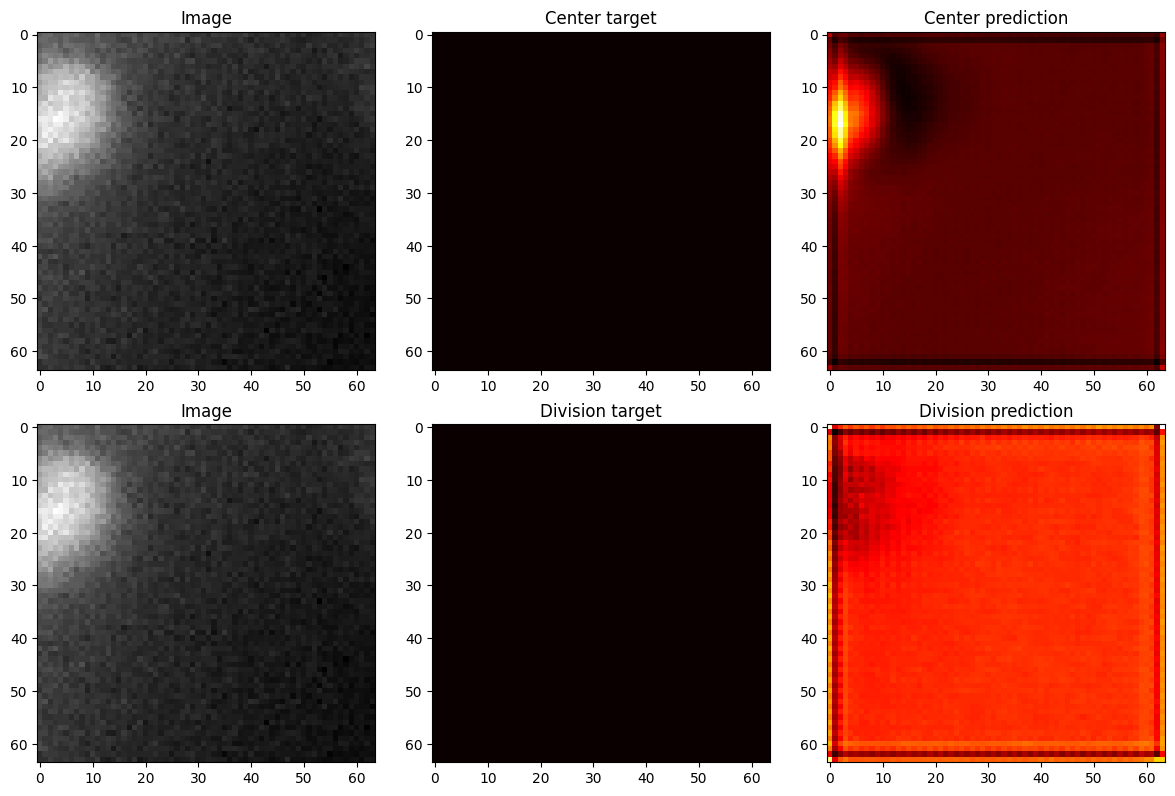

In [11]:

import matplotlib.pyplot as plt

img = images[0, 0].cpu().numpy()                    # (32,64,64)
pred = pred_centers[0, 0].detach().cpu().numpy()
target = targets[0, 0].cpu().numpy()
pred_d = pred_div[0, 0].detach().cpu().numpy()
target_d = div[0, 0].cpu().numpy()

z_slice = 16  # middle of your 32-depth patch

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(img[z_slice], cmap='gray'); axes[0, 0].set_title("Image")
axes[0, 1].imshow(target[z_slice], cmap='hot'); axes[0, 1].set_title("Center target")
axes[0, 2].imshow(pred[z_slice], cmap='hot'); axes[0, 2].set_title("Center prediction")
axes[1, 0].imshow(img[z_slice], cmap='gray'); axes[1, 0].set_title("Image")
axes[1, 1].imshow(target_d[z_slice], cmap='hot'); axes[1, 1].set_title("Division target")
axes[1, 2].imshow(pred_d[z_slice], cmap='hot'); axes[1, 2].set_title("Division prediction")
plt.tight_layout()
plt.show()


In [12]:

import numpy as np
import torch

def predict_full_volume_batched(model, full_volume, patch_size=(1,32,64,64), stride=(1,16,32,32), batch_size=16):
    pt, pz, py, px = patch_size
    st, sz, sy, sx = stride
    t_max, z_max, y_max, x_max = full_volume.shape
    
    output = np.zeros((t_max, z_max, y_max, x_max), dtype=np.float32)
    div_output = np.zeros((t_max, z_max, y_max, x_max), dtype=np.float32)
    counts = np.zeros_like(output)
    
    # Pre-calculate all patch coordinates to process them in batches
    patch_coords = []
    for t0 in range(0, t_max, st):
        for z0 in range(0, max(1, z_max - pz + 1), sz):
            for y0 in range(0, max(1, y_max - py + 1), sy):
                for x0 in range(0, max(1, x_max - px + 1), sx):
                    # Check if patch fits within bounds
                    if (t0 + pt <= t_max) and (z0 + pz <= z_max) and (y0 + py <= y_max) and (x0 + px <= x_max):
                        patch_coords.append((t0, z0, y0, x0))
                        
    model.eval()
    with torch.no_grad():
        # Process patches in chunks of 'batch_size'
        for i in range(0, len(patch_coords), batch_size):
            batch_coords_chunk = patch_coords[i : i + batch_size]
            
            # Extract patches and stack into a single large CPU numpy array
            patches_list = []
            for t0, z0, y0, x0 in batch_coords_chunk:
                p = full_volume[t0:t0+pt, z0:z0+pz, y0:y0+py, x0:x0+px]
                # Keep spatial dimensions (1, pz, py, px) -> (pz, py, px) based on your original logic
                patches_list.append(p.squeeze(0)) 
                
            # One single transfer to GPU for the entire batch
            # Shape changes from (B, pz, py, px) -> (B, 1, pz, py, px) for U-Net channel dimension
            batch_tensor = torch.tensor(np.array(patches_list), dtype=torch.float32).unsqueeze(1).to(device)
            
            # Forward pass on GPU -- model now returns (center, division) predictions
            preds_center, preds_div = model(batch_tensor)
            preds_center = preds_center.squeeze(1)  # Drop channel dimension -> (B, pz, py, px)
            preds_div = preds_div.squeeze(1)
            preds_center_np = preds_center.cpu().numpy()
            preds_div_np = preds_div.cpu().numpy()
            
            # Map predictions back to the output volumes
            for idx, (t0, z0, y0, x0) in enumerate(batch_coords_chunk):
                output[t0, z0:z0+pz, y0:y0+py, x0:x0+px] += preds_center_np[idx]
                div_output[t0, z0:z0+pz, y0:y0+py, x0:x0+px] += preds_div_np[idx]
                counts[t0, z0:z0+pz, y0:y0+py, x0:x0+px] += 1
                
    # Safeguard against zero division
    counts[counts == 0] = 1
    return output / counts, div_output / counts


In [13]:
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.segmentation import watershed

values = np.array(list(zarrDictTest.values()))
names = np.array(list(zarrDictTest.keys()))
id = 0
print("here")

print("there")


here
there


In [14]:

centroidsDict = {}
divPredDict = {}
for i in range(len(values)):
    print(f"Data: {names[i]}")
    full_pred, full_div_pred = predict_full_volume_batched(model, values[i])
    full_name = names[i]
    divPredDict[full_name] = full_div_pred  # keep the division heatmap around; not yet wired into
                                              # LapTrack's cost function -- see note below
    all_centroids = []
    for t in range(full_pred.shape[0]):
        print(f"{t}:time")
        frame = full_pred[t]  # (z, y, x)
        thresh = max(0.25 * frame.max(), 0.02)
        binary_mask = frame > thresh
        distance = ndi.distance_transform_edt(binary_mask)
        coords = peak_local_max(distance, min_distance=3, labels=binary_mask)
        if coords.shape[0] == 0:
            print(f"t={t}: no peaks found, skipping")
            continue
        seed_mask = np.zeros(distance.shape, dtype=bool)
        seed_mask[tuple(coords.T)] = True
        markers, _ = ndi.label(seed_mask)
        labels = watershed(-distance, markers, mask=binary_mask)
    
        label_ids = np.unique(labels)
        label_ids = label_ids[label_ids != 0]
        if len(label_ids) == 0:
            continue
        centroids = ndi.center_of_mass(labels, labels, index=label_ids)  # single vectorized call
    
        for lbl, (z, y, x) in zip(label_ids, centroids):
            all_centroids.append({
                #"id": f"{t}_{lbl}",  # unique across the whole dataframe, not just within a frame
                "t": t, "z": z, "y": y, "x": x,
            })
    
    centroids_df = pd.DataFrame(all_centroids)
    print(f"Done. Found {len(centroids_df)} centroids across {full_pred.shape[0]} timepoints.")
    centroidsDict[f"{names[i]}"] = centroids_df
    print("next")

print("done")

# NOTE: divPredDict now holds a per-voxel division-probability volume for each
# dataset. The tracking step below still uses LapTrack's geometric
# splitting_cutoff to call divisions. A natural next step is to sample
# divPredDict at each detected centroid's (t, z, y, x) and use that score to
# bias/filter LapTrack's proposed splits, rather than relying on distance alone.


Data: 44b6_0113de3bZarr
0:time
1:time
2:time
3:time
4:time
5:time
6:time
7:time
8:time
9:time
10:time
11:time
12:time
13:time
14:time
15:time
16:time
17:time
18:time
19:time
20:time
21:time
22:time
23:time
24:time
25:time
26:time
27:time
28:time
29:time
30:time
31:time
32:time
33:time
34:time
35:time
36:time
37:time
38:time
39:time
40:time
41:time
42:time
43:time
44:time
45:time
46:time
47:time
48:time
49:time
50:time
51:time
52:time
53:time
54:time
55:time
56:time
57:time
58:time
59:time
60:time
61:time
62:time
63:time
64:time
65:time
66:time
67:time
68:time
69:time
70:time
71:time
72:time
73:time
74:time
75:time
76:time
77:time
78:time
79:time
80:time
81:time
82:time
83:time
84:time
85:time
86:time
87:time
88:time
89:time
90:time
91:time
92:time
93:time
94:time
95:time
96:time
97:time
98:time
99:time
Done. Found 73993 centroids across 100 timepoints.
next
Data: 44b6_0b24845fZarr
0:time
1:time
2:time
3:time
4:time
5:time
6:time
7:time
8:time
9:time
10:time
11:time
12:time
13:time
14:t

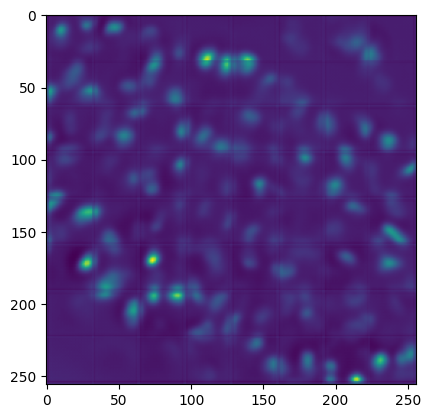

In [15]:
plt.imshow(full_pred[0][32])

In [16]:
import laptrack

lt = laptrack.LapTrack(cutoff=100**2, splitting_cutoff=20**2)


In [17]:

# --- nodes: track_df as-is, plus the columns submission needs ---
# NOTE: node_id is LOCAL to each dataset (matches sample_submission.csv,
# where node_id restarts per dataset). source_id/target_id on edge rows
# reference that local node_id -- NOT the global "id" column. Missing
# values use the -1 sentinel throughout, matching the sample format.
dfs = []
running_id = 0
for key, item in centroidsDict.items():
    track_df, split_df, merge_df = lt.predict_dataframe(
        item,
        coordinate_cols=["z", "x", "y"],
        frame_col="t"
    )
    track_df = track_df.reset_index(drop=True)
    track_df["node_id"] = range(1, len(track_df) + 1)  # 1-indexed, local to this dataset
    track_df["row_type"] = "node"
    track_df["dataset"] = key
    track_df["source_id"] = -1
    track_df["target_id"] = -1

    # --- within-track edges: shift each track_id's rows by one frame ---
    track_df_sorted = track_df.sort_values(["track_id", "t"])
    same_track = track_df_sorted["track_id"] == track_df_sorted["track_id"].shift(-1)

    within_edges = pd.DataFrame({
        "source_id": track_df_sorted["node_id"][same_track],
        "target_id": track_df_sorted["node_id"].shift(-1)[same_track],
    })

    # --- division edges: map parent's last node_id -> child's first node_id ---
    last_node = track_df.loc[track_df.groupby("track_id")["t"].idxmax(), ["track_id", "node_id"]].set_index("track_id")["node_id"]
    first_node = track_df.loc[track_df.groupby("track_id")["t"].idxmin(), ["track_id", "node_id"]].set_index("track_id")["node_id"]

    division_edges = pd.DataFrame({
        "source_id": split_df["parent_track_id"].map(last_node),
        "target_id": split_df["child_track_id"].map(first_node),
    })
    # a split at the very first/last frame can fail to map -- drop rather than submit NaN
    division_edges = division_edges.dropna(subset=["source_id", "target_id"])

    # --- combine everything ---
    edges_df = pd.concat([within_edges, division_edges], ignore_index=True)
    edges_df["row_type"] = "edge"
    edges_df["dataset"] = key
    edges_df["node_id"] = -1
    edges_df["t"] = -1
    edges_df["z"] = -1
    edges_df["y"] = -1
    edges_df["x"] = -1

    submission_df = pd.concat([track_df, edges_df], ignore_index=True)
    # only the "id" column is global/unique across the whole file
    submission_df.insert(0, "id", range(running_id, running_id + len(submission_df)))
    running_id += len(submission_df)

    submission_df = submission_df[["id", "dataset", "row_type", "node_id", "t", "z", "y", "x", "source_id", "target_id"]]
    dfs.append(submission_df)

print("done")


done


In [18]:

submission_final = pd.concat(dfs, ignore_index=True)

# match sample_submission.csv exactly: every column is int64, no NaNs/strings
int_cols = ["id", "node_id", "t", "z", "y", "x", "source_id", "target_id"]
for c in int_cols:
    submission_final[c] = submission_final[c].round().astype(int)

submission_final.to_csv("submission.csv", index=False)